In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from  sklearn.linear_model import LinearRegression

In [3]:
cars = pd.read_csv("Cars.csv")
cars

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


In [4]:
cars.isna().sum()

HP     0
MPG    0
VOL    0
SP     0
WT     0
dtype: int64

In [6]:
cars.shape

(81, 5)

In [7]:
cars.dtypes

HP       int64
MPG    float64
VOL      int64
SP     float64
WT     float64
dtype: object

In [8]:
del cars["SP"]

In [10]:
del cars["WT"]

In [11]:
cars.describe()

,HP,MPG,VOL
count,81.000000,81.000000,81.000000
mean,117.469136,34.422076,98.765432
std,57.113502,9.131445,22.301497
min,49.000000,12.101263,50.000000
25%,84.000000,27.856252,89.000000
50%,100.000000,35.152727,101.000000
75%,140.000000,39.531633,113.000000
max,322.000000,53.700681,160.000000


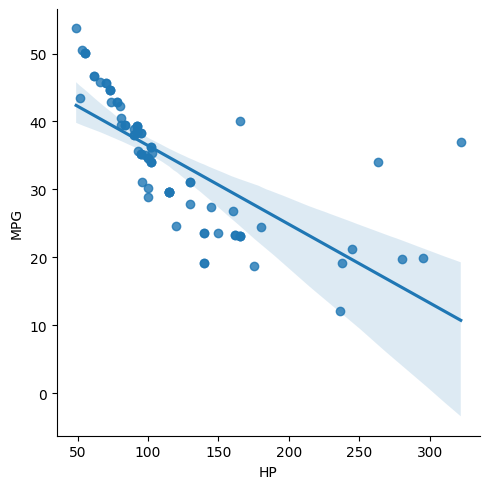

In [13]:
# linearity Test
sns.lmplot(data=cars,x="HP",y="MPG")

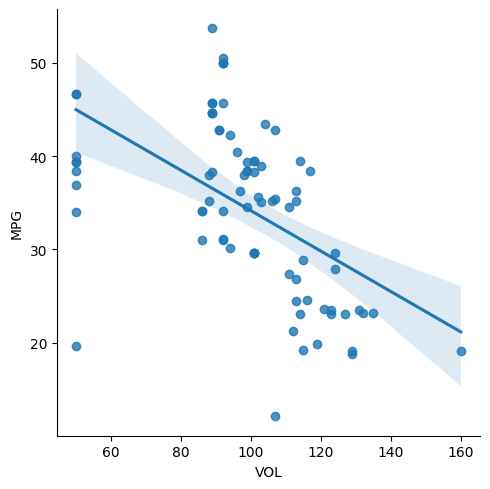

In [14]:
sns.lmplot(data=cars,x="VOL",y="MPG")

(array([15., 35.,  9.,  6.,  9.,  0.,  2.,  2.,  1.,  2.]),
 array([ 49. ,  76.3, 103.6, 130.9, 158.2, 185.5, 212.8, 240.1, 267.4,
        294.7, 322. ]),
 <BarContainer object of 10 artists>)

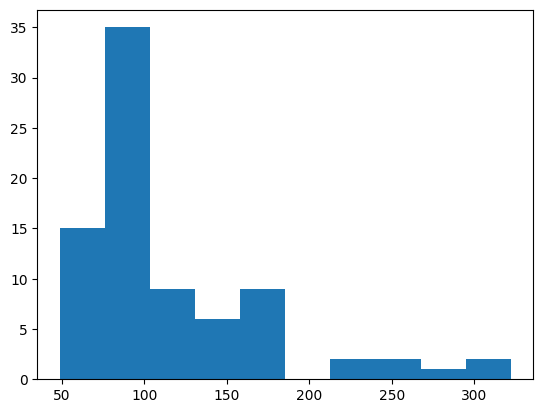

In [16]:
# Normality Test

plt.hist(cars["HP"])

(array([ 9.,  0.,  0., 22., 20., 15.,  8.,  6.,  0.,  1.]),
 array([ 50.,  61.,  72.,  83.,  94., 105., 116., 127., 138., 149., 160.]),
 <BarContainer object of 10 artists>)

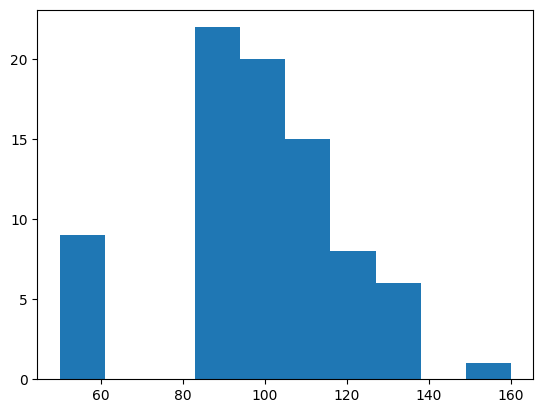

In [18]:
plt.hist(cars["VOL"])

In [21]:
corr_matrix=cars.corr()
corr_matrix

,HP,MPG,VOL
HP,1.000000,-0.725038,0.077459
MPG,-0.725038,1.000000,-0.529057
VOL,0.077459,-0.529057,1.000000


<Axes: >

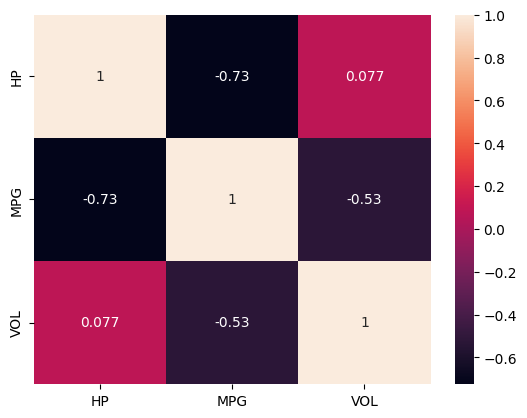

In [24]:
sns.heatmap(corr_matrix,annot=True)

In [25]:
cars.describe()

,HP,MPG,VOL
count,81.000000,81.000000,81.000000
mean,117.469136,34.422076,98.765432
std,57.113502,9.131445,22.301497
min,49.000000,12.101263,50.000000
25%,84.000000,27.856252,89.000000
50%,100.000000,35.152727,101.000000
75%,140.000000,39.531633,113.000000
max,322.000000,53.700681,160.000000


In [27]:
X = cars[["HP","VOL"]]
X

,HP,VOL
0,49,89
1,55,92
2,55,92
3,70,92
4,53,92
...,...,...
76,322,50
77,238,115
78,263,50
79,295,119


In [28]:
y=cars["MPG"]
y

0     53.700681
1     50.013401
2     50.013401
3     45.696322
4     50.504232
        ...    
76    36.900000
77    19.197888
78    34.000000
79    19.833733
80    12.101263
Name: MPG, Length: 81, dtype: float64

In [29]:
linear_model = LinearRegression()

In [30]:
linear_model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [31]:
linear_model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
linear_model.intercept_

np.float64(66.58638502425589)

In [34]:
linear_model.coef_

array([-0.110029  , -0.19479789])

In [35]:
y_pred= linear_model.predict(X)

In [36]:
y_pred

array([43.8579519 , 42.61338422, 42.61338422, 40.96294921, 42.83344223,
       41.54734287, 42.61338422, 50.02469253, 50.02469253, 39.47306342,
       41.21725587, 46.7238225 , 37.17872597, 41.21725587, 41.98745888,
       41.21725587, 40.27751509, 46.7238225 , 40.27751509, 36.61959241,
       37.17872597, 37.60086488, 36.45904319, 38.97343864, 38.79661785,
       46.7238225 , 33.67236397, 37.17872597, 40.60589657, 34.41002385,
       35.13698965, 37.6693622 , 36.46803173, 33.35126552, 37.9994492 ,
       37.59358186, 39.54156074, 38.61080851, 38.61080851, 34.36120915,
       34.12146852, 35.48505374, 37.44202118, 38.99141574, 36.4843033 ,
       36.29849396, 33.9609193 , 35.73936041, 35.52999648, 34.25846316,
       34.25846316, 34.25846316, 29.77811173, 24.76900343, 26.96958346,
       28.12767671, 38.10219518, 34.25846316, 37.2724834 , 33.18172774,
       29.00961425, 30.78634983, 25.66380148, 27.22218459, 26.51149036,
       38.69170543, 26.22464056, 23.69226801, 24.47145957, 17.81

In [37]:
error = y- y_pred

In [38]:
error

0      9.842729
1      7.400017
2      7.400017
3      4.733373
4      7.670790
        ...    
76    15.482848
77     1.200162
78     6.091137
79     8.886852
80    -7.674904
Name: MPG, Length: 81, dtype: float64

<Axes: xlabel='HP', ylabel='MPG'>

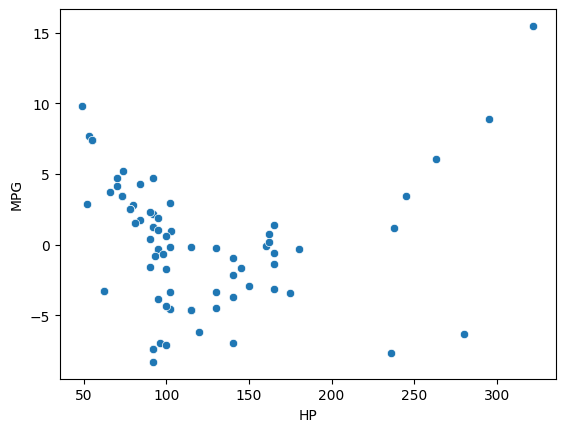

In [41]:
sns.scatterplot(data=cars,x="HP",y=error)

<Axes: xlabel='VOL', ylabel='MPG'>

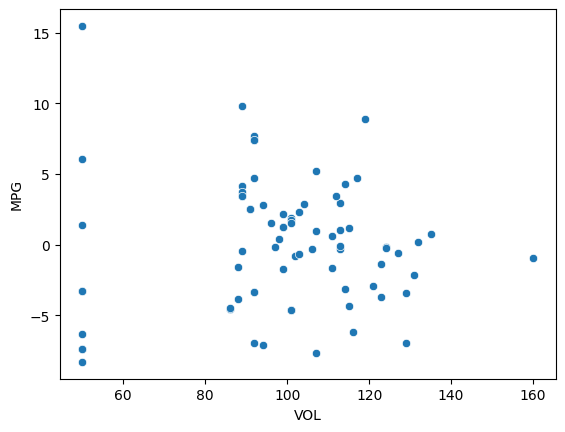

In [42]:
sns.scatterplot(data=cars,x="VOL",y=error)

<Axes: xlabel='MPG'>

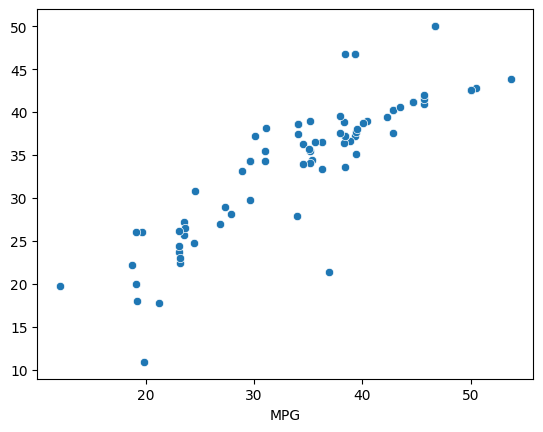

In [44]:
sns.scatterplot(x=cars["MPG"],y=y_pred)